# Benchmark v5 — GPU — FreeSolv — scaffold split, seed 1

**Task:** Predict experimental hydration free energy in kcal/mol
**Size:** ~642 molecules
**Metric:** RMSE ↓, MAE ↓, R² ↑

**Scaffold split**, seed **1** — GIN, D-MPNN, SchNet, LSTM with Optuna HPO.

Results go to `results/seed_1/scaffold/`.


In [1]:
# NOTE: autoreload is intentionally NOT enabled. With C-extension packages
# (numpy, torch, torch_geometric) `%autoreload 2` reloads them mid-run and
# corrupts their state (numpy RecursionError / torch_geometric circular
# import). If you edit the benchmark modules, restart the kernel instead.
import os
# Avoid XGBoost/OpenMP segfaults in Jupyter on macOS (OMP Error #179).
for _omp_var in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[_omp_var] = "1"

import sys
from pathlib import Path

ROOT = Path(".").resolve()
for _ in range(6):
    if (ROOT / "mol_repr_utils.py").exists():
        break
    ROOT = ROOT.parent
else:
    raise FileNotFoundError("Could not find benchmark_v5 root (mol_repr_utils.py)")
sys.path.insert(0, str(ROOT))

from mol_repr_utils import *
from split_utils import (
    get_or_create_splits, subset_array, subset_list, subset_graphs_by_valid_idx,
    check_split_proportions,
)
from conformer_generation import load_conformer_graphs
from hpo_utils import (
    hpo_tabular, hpo_gnn, hpo_schnet, hpo_lstm,
    save_hpo_params, hpo_params_path,
)
from hpo_config import SKLEARN_HPO_N_ITER

DATA_DIR = ROOT / "data"

DEVICE = get_device()
print(f"Benchmark v5 (GPU) code root: {ROOT}")
print(f"Device: {DEVICE}")
print("Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.")


INFO | Using device: cpu (request a GPU node on the cluster for large GNN/LSTM jobs)


Benchmark v5 (GPU) code root: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5
Device: cpu
Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.


In [2]:
DATASET_SLUG = "freesolv"
TASK_TYPE = "regression"
OUT_CHANNELS = 1
BATCH_SIZE = 32
GNN_EPOCHS = 120
LSTM_EPOCHS = 120
TOX21_TABULAR = False

HPO_EPOCHS = 80  # Optuna trial length; GNN_EPOCHS for final refit
HPO_N_TRIALS = 20
print(f"GPU HPO tier: standard — {HPO_N_TRIALS} trials, {HPO_EPOCHS} epochs/trial, batch={BATCH_SIZE}")

SPLIT_MODE = "scaffold"   # "scaffold" or "random"
SPLIT_SEED = 1

RESULTS_ROOT = ROOT / "results" / f"seed_{SPLIT_SEED}" / SPLIT_MODE
RESULTS_DIR = RESULTS_ROOT / "gpu"
SPLITS_DIR = RESULTS_ROOT / "splits"
HPO_DIR = RESULTS_DIR / "hpo"
HISTORY_DIR = RESULTS_DIR / "histories"
for d in (RESULTS_DIR, SPLITS_DIR, HPO_DIR, HISTORY_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f"Results → {RESULTS_ROOT}")

PARTIAL_PATH = RESULTS_DIR / f"{DATASET_SLUG}_partial.json"
FRESH_RUN = False
HPO_N_ITER = SKLEARN_HPO_N_ITER

if FRESH_RUN:
    reset_dataset_run(
        DATASET_SLUG, RESULTS_DIR,
        results_root=RESULTS_ROOT, split_mode=SPLIT_MODE,
    )
    print("Fresh run — cleared partial results and splits.")

results = load_partial_results(PARTIAL_PATH)
if results:
    print(f"Resuming {len(results)} saved model(s): {', '.join(order_results(results).keys())}")
print(f"SPLIT_SEED={SPLIT_SEED}  mode={SPLIT_MODE}")


GPU HPO tier: standard — 20 trials, 80 epochs/trial, batch=32
Results → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold
SPLIT_SEED=1  mode=scaffold


### Load data


In [3]:
import numpy as np
import pandas as pd

df = load_dataset("freesolv", cache_dir=DATA_DIR)
smiles, y = preprocess_dataset(df, "freesolv")
print(f"Molecules : {len(smiles)}")
print(f"Target    : [{y.min():.2f}, {y.max():.2f}]  mean={y.mean():.2f} kcal/mol")
smiles, y = filter_bonded_molecules(smiles, y)
print(f'After bond filter: {len(smiles)} molecules')


INFO | Loading 'freesolv' from cache: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/freesolv.csv
INFO | [freesolv] 642 / 642 valid molecules


Molecules : 642
Target    : [-25.47, 3.43]  mean=-3.80 kcal/mol
After bond filter: 639 molecules


### Representations & scaffold split


In [4]:
graphs2d_all = smiles_to_graphs(smiles, y)
graphs_dmpnn_all = smiles_to_dmpnn_graphs(smiles, y)
X_tok_all, vocab = tokenize_smiles(smiles)

graphs3d_all, valid_idx_3d, _ = load_conformer_graphs(
    DATASET_SLUG, data_dir=DATA_DIR, n_confs=25
)
graphs3d_all = ensure_atomic_numbers_list(graphs3d_all)
print(f"3D graphs loaded: {len(graphs3d_all)} / {len(smiles)} (valid_idx mapping)")

split_data = get_or_create_splits(
    smiles, RESULTS_ROOT, DATASET_SLUG,
    mode=SPLIT_MODE, seed=SPLIT_SEED, force=FRESH_RUN,
)
train_idx = split_data["train_idx"]
val_idx = split_data["val_idx"]
test_idx = split_data["test_idx"]
check_split_proportions(train_idx, val_idx, test_idx, raise_on_fail=True)
print(split_data["summary"])

tr2d = subset_list(graphs2d_all, train_idx)
va2d = subset_list(graphs2d_all, val_idx)
te2d = subset_list(graphs2d_all, test_idx)

tr_dmpnn = subset_list(graphs_dmpnn_all, train_idx)
va_dmpnn = subset_list(graphs_dmpnn_all, val_idx)
te_dmpnn = subset_list(graphs_dmpnn_all, test_idx)

tr3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, train_idx)
va3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, val_idx)
te3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, test_idx)

tr_ds = SMILESDataset(subset_array(X_tok_all, train_idx), subset_array(y, train_idx))
va_ds = SMILESDataset(subset_array(X_tok_all, val_idx), subset_array(y, val_idx))
te_ds = SMILESDataset(subset_array(X_tok_all, test_idx), subset_array(y, test_idx))


INFO | Loaded 642 / 642 graphs from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/freesolv_conformers_n25.pkl  (n_confs=25)
INFO | Loaded splits from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/splits/freesolv_scaffold_splits.pkl


3D graphs loaded: 642 / 639 (valid_idx mapping)
{'n_total': 639, 'n_train': 511, 'n_val': 64, 'n_test': 64, 'n_scaffolds_total': 63, 'n_scaffolds_train': 5, 'n_scaffolds_val': 10, 'n_scaffolds_test': 48}


### GIN (2D)


In [5]:
MODEL_KEY = "GIN (2D)"
tr = tr3d if "2D" == "3D" else tr2d
va = va3d if "2D" == "3D" else va2d
te = te3d if "2D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (2D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | GIN 2D — starting trial 1/20 (layers=3, hidden=192)


→ GIN (2D) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=12.5272 | val={'RMSE': 5.891874051452303, 'MAE': 4.125103794038296, 'R2': 0.027497110361755728}
INFO | HPO epoch   5/80 | loss=1.8685 | val={'RMSE': 1.9846568841400154, 'MAE': 1.6680334939155728, 'R2': 0.8896544404492257}
INFO | HPO epoch  10/80 | loss=2.0315 | val={'RMSE': 2.0957213389940326, 'MAE': 1.7706642700359225, 'R2': 0.8769586571262558}
INFO | HPO epoch  15/80 | loss=1.3541 | val={'RMSE': 2.053410939864457, 'MAE': 1.5728232378605753, 'R2': 0.8818766556548115}
INFO | HPO epoch  20/80 | loss=0.8149 | val={'RMSE': 1.7524583349509621, 'MAE': 1.2252996442839503, 'R2': 0.9139641618172636}
INFO | HPO epoch  25/80 | loss=0.7787 | val={'RMSE': 1.9620422486556477, 'MAE': 1.478490340989083, 'R2': 0.8921548295872267}
INFO | HPO epoch  30/80 | loss=0.8280 | val={'RMSE': 2.057070445954194, 'MAE': 1.4166634727735072, 'R2': 0.8814552511717586}
INFO | Early stop at epoch 32 (patience=15)
INFO | GIN 2D HPO — trial 1/20 finished | val=1.493006 | best=1.493006
INFO 

   scaffold test: {'RMSE': 3.187184552685433, 'MAE': 2.4611481418833137, 'R2': 0.25305669828312716}


### D-MPNN (2D)
Bond-centric directed MPNN (Yang et al. 2019).


In [6]:
MODEL_KEY = "D-MPNN (2D)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr_dmpnn, va_dmpnn, TASK_TYPE, "DMPNN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("DMPNN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr_dmpnn, va_dmpnn, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te_dmpnn, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_dmpnn.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | DMPNN 2D — starting trial 1/20 (layers=3, hidden=192)


→ D-MPNN (2D) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=11.5880 | val={'RMSE': 6.02152374480595, 'MAE': 4.425571756437421, 'R2': -0.01577331144069083}
INFO | HPO epoch   5/80 | loss=4.3113 | val={'RMSE': 3.9583074804861496, 'MAE': 2.6855871434672736, 'R2': 0.5610621363229567}
INFO | HPO epoch  10/80 | loss=1.1545 | val={'RMSE': 1.8702472376295445, 'MAE': 1.3491377800237387, 'R2': 0.9020099373485151}
INFO | HPO epoch  15/80 | loss=0.7877 | val={'RMSE': 2.0378938306091787, 'MAE': 1.3620022993418388, 'R2': 0.8836551670072735}
INFO | HPO epoch  20/80 | loss=0.5444 | val={'RMSE': 2.677281777697401, 'MAE': 1.8057343950495124, 'R2': 0.7991960943648818}
INFO | HPO epoch  25/80 | loss=0.4709 | val={'RMSE': 2.1868741545378625, 'MAE': 1.4421072849072516, 'R2': 0.8660225908170146}
INFO | HPO epoch  30/80 | loss=0.4479 | val={'RMSE': 2.250664009890362, 'MAE': 1.4406943274661899, 'R2': 0.85809250823554}
INFO | HPO epoch  35/80 | loss=0.3873 | val={'RMSE': 2.223906267957582, 'MAE': 1.4462972185574472, 'R2': 0.861446676038478

   scaffold test: {'RMSE': 2.954735860789739, 'MAE': 2.173596148379147, 'R2': 0.35803619936876885}


### GIN (3D)


In [7]:
MODEL_KEY = "GIN (3D)"
tr = tr3d if "3D" == "3D" else tr2d
va = va3d if "3D" == "3D" else va2d
te = te3d if "3D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "3D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "3D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (3D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | GIN 3D — starting trial 1/20 (layers=3, hidden=192)


→ GIN (3D) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=12.6725 | val={'RMSE': 4.333962205371977, 'MAE': 2.9098262889310718, 'R2': -0.013675798869123401}
INFO | HPO epoch   5/80 | loss=2.8020 | val={'RMSE': 1.916746848654793, 'MAE': 1.3638227449264377, 'R2': 0.8017293846821132}
INFO | HPO epoch  10/80 | loss=1.7541 | val={'RMSE': 1.4077660099577611, 'MAE': 1.030367841012776, 'R2': 0.8930477836533267}
INFO | HPO epoch  15/80 | loss=1.4869 | val={'RMSE': 1.5594291930318964, 'MAE': 1.1374432165175676, 'R2': 0.8687618321509112}
INFO | HPO epoch  20/80 | loss=1.2376 | val={'RMSE': 1.1943314848795532, 'MAE': 0.8284518364816904, 'R2': 0.9230198769116458}
INFO | HPO epoch  25/80 | loss=1.8402 | val={'RMSE': 1.4923219702448371, 'MAE': 0.9671830218285322, 'R2': 0.8798139936760832}
INFO | HPO epoch  30/80 | loss=1.0796 | val={'RMSE': 1.8446401217373811, 'MAE': 1.2000748575665057, 'R2': 0.8163664036905334}
INFO | HPO epoch  35/80 | loss=0.8400 | val={'RMSE': 1.209858240651001, 'MAE': 0.8120773676782846, 'R2': 0.9210053257

   scaffold test: {'RMSE': 1.058435492379166, 'MAE': 0.7016146619571373, 'R2': 0.9041954142325089}


### SchNet (3D coords)
Uses atomic numbers + xyz from min-energy n=25 conformer.


In [8]:
MODEL_KEY = "SchNet (3D coords)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_schnet(
        tr3d, va3d, TASK_TYPE, OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_schnet, PyGLoader, build_schnet, train_schnet
    model = build_schnet(
        OUT_CHANNELS,
        hidden_channels=best["hidden_channels"],
        num_filters=best["num_filters"],
        num_interactions=best["num_interactions"],
        num_gaussians=best["num_gaussians"],
        cutoff=best["cutoff"],
    )
    train_schnet(model, tr3d, va3d, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
                 batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    te3d_schnet = ensure_atomic_numbers_list(te3d)
    test_metrics = eval_schnet(model, PyGLoader(te3d_schnet, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_schnet.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | SchNet — starting trial 1/20


→ SchNet (3D coords) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=21.3276 | val={'RMSE': 4.198079874651058, 'MAE': 2.8953338651917875, 'R2': 0.04889112666977069}
INFO | HPO epoch   5/80 | loss=6.3569 | val={'RMSE': 3.150410447513002, 'MAE': 2.3479074626229703, 'R2': 0.46437219126737717}
INFO | HPO epoch  10/80 | loss=4.3476 | val={'RMSE': 2.4187147755036698, 'MAE': 1.774899713229388, 'R2': 0.6842828644428591}
INFO | HPO epoch  15/80 | loss=2.5396 | val={'RMSE': 1.89676452919609, 'MAE': 1.3821885643992573, 'R2': 0.8058418266531269}
INFO | HPO epoch  20/80 | loss=2.1079 | val={'RMSE': 1.7510011805632388, 'MAE': 1.2832980738021433, 'R2': 0.8345366867667423}
INFO | HPO epoch  25/80 | loss=1.6716 | val={'RMSE': 1.589722965927506, 'MAE': 1.1457790192216635, 'R2': 0.8636133898605889}
INFO | HPO epoch  30/80 | loss=1.2172 | val={'RMSE': 1.6766179917250483, 'MAE': 1.132998550310731, 'R2': 0.8482959821699847}
INFO | HPO epoch  35/80 | loss=0.8819 | val={'RMSE': 1.6369265820841667, 'MAE': 1.1522083077579737, 'R2': 0.85539369099297

   scaffold test: {'RMSE': 0.8476455593694281, 'MAE': 0.5856600672705099, 'R2': 0.9385550647803752}


### SMILES LSTM
Canonical isomeric SMILES tokens.


In [9]:
MODEL_KEY = "SMILES LSTM"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_lstm(
        tr_ds, va_ds, TASK_TYPE, len(vocab), OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import SmilesLSTM, eval_lstm, TorchLoader, train_lstm
    model = SmilesLSTM(len(vocab), embed_dim=best["embed_dim"], hidden_dim=best["hidden_dim"],
                       n_layers=best["n_layers"], out_channels=OUT_CHANNELS, dropout=best["dropout"])
    train_lstm(model, tr_ds, va_ds, TASK_TYPE, epochs=LSTM_EPOCHS, lr=best["lr"],
               batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_lstm(model, TorchLoader(te_ds, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_lstm.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | LSTM — starting trial 1/20


→ SMILES LSTM (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=17.1218 | val={'RMSE': 6.809499287441838, 'MAE': 4.398428939282894, 'R2': -0.29901554728707413}
INFO | HPO epoch   5/80 | loss=4.3958 | val={'RMSE': 4.891857043033612, 'MAE': 3.376231729751453, 'R2': 0.3296038595406158}
INFO | HPO epoch  10/80 | loss=2.8068 | val={'RMSE': 4.740998733765866, 'MAE': 3.148783002514392, 'R2': 0.3703145328870747}
INFO | HPO epoch  15/80 | loss=1.9808 | val={'RMSE': 4.128796743719703, 'MAE': 2.7841517199994996, 'R2': 0.5224366406570753}
INFO | HPO epoch  20/80 | loss=1.4480 | val={'RMSE': 3.45841408085983, 'MAE': 2.107450006529689, 'R2': 0.6649281272942098}
INFO | HPO epoch  25/80 | loss=1.1912 | val={'RMSE': 3.2235111462947375, 'MAE': 1.9577455390244722, 'R2': 0.7088999071658643}
INFO | HPO epoch  30/80 | loss=0.9653 | val={'RMSE': 2.987435486356431, 'MAE': 1.9204863808117807, 'R2': 0.749976366477075}
INFO | HPO epoch  35/80 | loss=0.8100 | val={'RMSE': 2.7439574146434706, 'MAE': 1.7368749231100082, 'R2': 0.7890698189788082}
I

   scaffold test: {'RMSE': 2.584511835178077, 'MAE': 1.8595617476967163, 'R2': 0.5088317744425472}


### Finalize GPU + merge


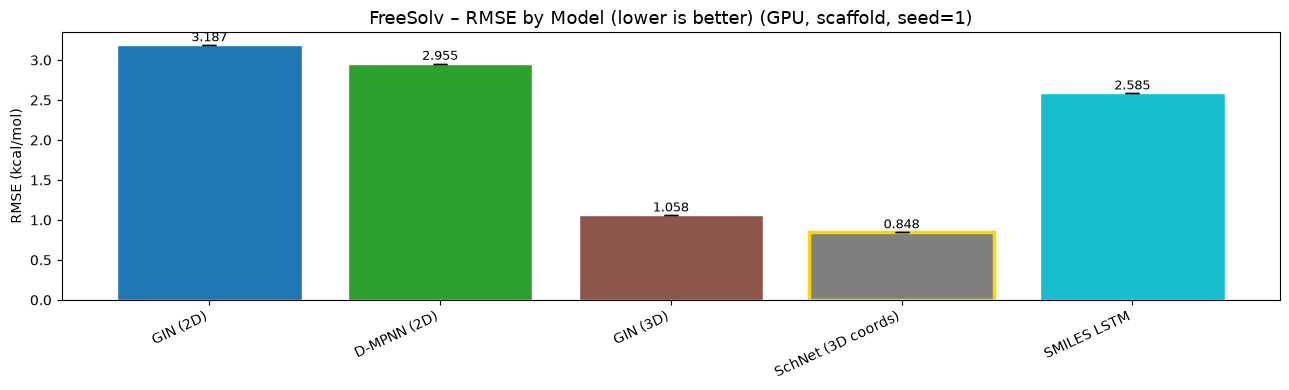

=== FREESOLV Results (5/12 models) ===
                               RMSE              MAE               R2
Model                                                                
GIN (2D)            3.1872 ± 0.0000  2.4611 ± 0.0000  0.2531 ± 0.0000
D-MPNN (2D)         2.9547 ± 0.0000  2.1736 ± 0.0000  0.3580 ± 0.0000
GIN (3D)            1.0584 ± 0.0000  0.7016 ± 0.0000  0.9042 ± 0.0000
SchNet (3D coords)  0.8476 ± 0.0000  0.5857 ± 0.0000  0.9386 ± 0.0000
SMILES LSTM         2.5845 ± 0.0000  1.8596 ± 0.0000  0.5088 ± 0.0000

Final CSV : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/gpu/freesolv_results.csv
Plot      : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/gpu/freesolv_rmse_comparison.png
Partial   : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmar

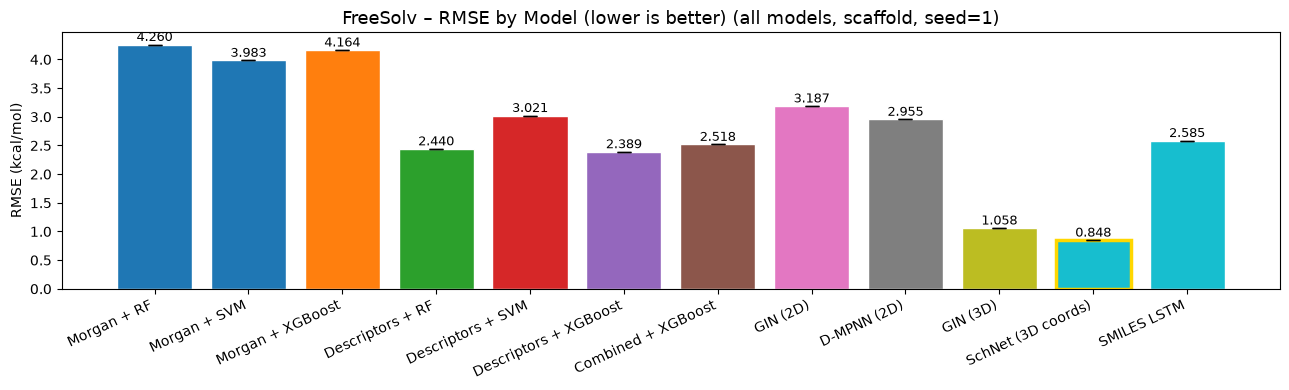

=== FREESOLV Results (12/12 models) ===
                                  RMSE              MAE                R2
Model                                                                    
Morgan + RF            4.2601 ± 0.0000  3.3460 ± 0.0000  -0.3345 ± 0.0000
Morgan + SVM           3.9828 ± 0.0000  3.0129 ± 0.0000  -0.1664 ± 0.0000
Morgan + XGBoost       4.1643 ± 0.0000  3.2417 ± 0.0000  -0.2751 ± 0.0000
Descriptors + RF       2.4398 ± 0.0000  1.8130 ± 0.0000   0.5623 ± 0.0000
Descriptors + SVM      3.0208 ± 0.0000  2.0337 ± 0.0000   0.3290 ± 0.0000
Descriptors + XGBoost  2.3894 ± 0.0000  1.5618 ± 0.0000   0.5802 ± 0.0000
Combined + XGBoost     2.5177 ± 0.0000  1.8181 ± 0.0000   0.5339 ± 0.0000
GIN (2D)               3.1872 ± 0.0000  2.4611 ± 0.0000   0.2531 ± 0.0000
D-MPNN (2D)            2.9547 ± 0.0000  2.1736 ± 0.0000   0.3580 ± 0.0000
GIN (3D)               1.0584 ± 0.0000  0.7016 ± 0.0000   0.9042 ± 0.0000
SchNet (3D coords)     0.8476 ± 0.0000  0.5857 ± 0.0000   0.9386 ± 0.000

In [10]:
finalize_dataset_results(DATASET_SLUG, PARTIAL_PATH, RESULTS_DIR, TASK_TYPE,
    plot_title=f"FreeSolv – RMSE by Model (lower is better) (GPU, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="RMSE (kcal/mol)", minimize=True)
cpu_partial = RESULTS_ROOT / "cpu" / f"{DATASET_SLUG}_partial.json"
if cpu_partial.exists():
    merge_combined_results(DATASET_SLUG, cpu_partial, PARTIAL_PATH, RESULTS_ROOT / "combined",
        TASK_TYPE, plot_title=f"FreeSolv – RMSE by Model (lower is better) (all models, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="RMSE (kcal/mol)", minimize=True)
else:
    print("Run CPU notebook first for combined results.")
